# Práctica — Ejercicio 2: Incendios forestales por causa y provincia

El dataset `incendios-cantidad-causas-provincia_2022.csv` contiene el número de incendios forestales
por provincia, año y causa para el período 1993-2021.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# El archivo tiene 3 filas de metadatos; el encabezado real está en la fila 3 (index 3)
df = pd.read_csv("../Datasets/incendios-cantidad-causas-provincia_2022.csv",
                  encoding='latin1', header=3)

# Limpieza
df['provincia'] = df['provincia'].str.strip()
df = df.dropna(subset=['anio', 'provincia'])
df['anio'] = df['anio'].astype(int)
# Asegurar que las columnas numéricas sean numéricas (algunas se leen como str)
for col in ['total', 'negligencia', 'intencional', 'natural', 'desconocida']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print(f"Shape: {df.shape}")
print("Columnas:", df.columns.tolist())
df.head(3)

Shape: (676, 7)
Columnas: ['anio', 'provincia', 'total', 'negligencia', 'intencional', 'natural', 'desconocida']


,anio,provincia,total,negligencia,intencional,natural,desconocida
0,1993,Buenos Aires,0,0,0,0,0
1,1993,Catamarca,0,0,0,0,0
2,1993,Chaco,0,0,0,0,0


## Ítem 1 — Número de incendios totales por año para todo el país

> **Obtenga el número de incendios totales por año para todo el país. ¿Cuál fue el año en el que se presentó un mayor número de incendios?**

In [3]:
por_anio = df.groupby('anio')['total'].sum().reset_index()
por_anio.columns = ['anio', 'total_pais']

print("Incendios totales por año (todo el país):")
print(por_anio.to_string(index=False))

anio_max = por_anio.loc[por_anio['total_pais'].idxmax()]
print(f"\nAño con mayor número de incendios: {int(anio_max['anio'])} ({int(anio_max['total_pais'])} incendios)")

Incendios totales por año (todo el país):
 anio  total_pais
 1993         538
 1994         852
 1995        4145
 1996        4057
 1997        4660
 1998        8681
 1999       10487
 2000       10559
 2001        7839
 2002       10566
 2003       12191
 2004       12629
 2005       17260
 2006       11321
 2007       10994
 2008       17682
 2009       10309
 2010        7504
 2011        6738
 2012        5599
 2013        6684
 2014        6951
 2015        6045
 2016        7478
 2017        7414
 2018        9136
 2019        6429
 2020       10477
 2021        6209

Año con mayor número de incendios: 2008 (17682 incendios)


## Ítem 2 — Incendios por año en Córdoba (1993–2021)

> **Obtenga el número de incendios totales por año para el período 1993-2021 en la provincia de Córdoba.**

In [4]:
cordoba = df[(df['provincia'] == 'C\u00f3rdoba') & (df['anio'].between(1993, 2021))]
cordoba_anio = cordoba[['anio', 'total']].sort_values('anio')
print("Incendios totales en Córdoba (1993-2021):")
print(cordoba_anio.to_string(index=False))

Incendios totales en Córdoba (1993-2021):
 anio  total
 1993    151
 1994    161
 1995   2441
 1996     92
 1997    387
 1998    307
 1999     55
 2000    869
 2001    194
 2002    101
 2003    119
 2004    154
 2006    438
 2007    346
 2008    157
 2009    229
 2011    147
 2012    135
 2013    173
 2014    291
 2019    273
 2020    264
 2021    198


## Ítem 3 — Provincia con más incendios intencionales por año

> **Realice una tabla en la que se muestre, para cada año del periodo 1993-2021, la provincia en la que tuvo lugar el mayor número de incendios intencionales.**

In [5]:
df_periodo = df[df['anio'].between(1993, 2021)].copy()

# Pivot: filas=año, columnas=provincia, valores=intencional
pivot = df_periodo.pivot_table(index='anio', columns='provincia',
                                values='intencional', aggfunc='sum', fill_value=0)

# Provincia con max intencionales por año
provincia_max = pivot.idxmax(axis=1).reset_index()
provincia_max.columns = ['anio', 'provincia_max_intencionales']

# Agregar el valor máximo
provincia_max['intencionales_max'] = pivot.max(axis=1).values

print("Provincia con mayor número de incendios intencionales por año:")
print(provincia_max.to_string(index=False))

Provincia con mayor número de incendios intencionales por año:
 anio provincia_max_intencionales  intencionales_max
 1993            Tierra del Fuego                  2
 1994                   Río Negro                  7
 1995                   Río Negro                250
 1996                   Catamarca               1662
 1997                   Río Negro                453
 1998                Buenos Aires                583
 1999                       Chaco                503
 2000                       Chaco                549
 2001                       Chaco                284
 2002                Buenos Aires                358
 2003                   Río Negro                790
 2004                    Santa Fe                290
 2005                     Cordoba                515
 2006                    Santa Fe                581
 2007                   Río Negro               1154
 2008                   Río Negro               1528
 2009                   Río Negro   

## Ítem 4 — Incendios en Santa Fe (2015–2021): gráfico de barras

> **Realice un gráfico de barras para visualizar el número de incendios intencionales, por negligencia y naturales que tuvieron lugar durante el periodo 2015-2021 en la provincia de Santa Fe.**

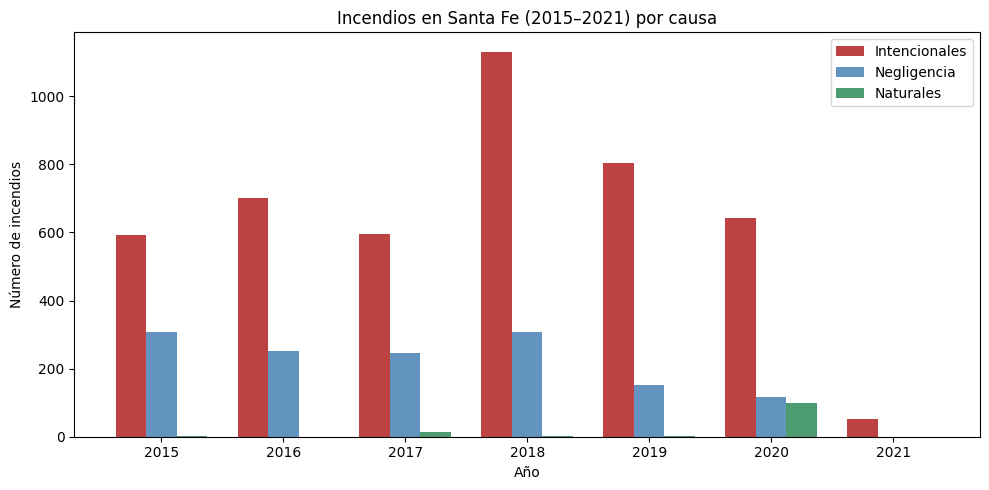

In [6]:
santa_fe = df[(df['provincia'] == 'Santa Fe') & (df['anio'].between(2015, 2021))]
santa_fe = santa_fe[['anio', 'intencional', 'negligencia', 'natural']].sort_values('anio')

x = santa_fe['anio'].values
width = 0.25
x_pos = range(len(x))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([p - width for p in x_pos], santa_fe['intencional'], width=width,
       label='Intencionales', color='firebrick', alpha=0.85)
ax.bar(x_pos, santa_fe['negligencia'], width=width,
       label='Negligencia', color='steelblue', alpha=0.85)
ax.bar([p + width for p in x_pos], santa_fe['natural'], width=width,
       label='Naturales', color='seagreen', alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(x)
ax.set_xlabel('Año')
ax.set_ylabel('Número de incendios')
ax.set_title('Incendios en Santa Fe (2015–2021) por causa')
ax.legend()
plt.tight_layout()
plt.show()

## Ítem 5 — Promedio de incendios en Río Negro (1993–2021)

> **Obtenga el número promedio de incendios intencionales, por negligencia y naturales para la provincia de Río Negro durante el periodo 1993-2021.**

In [7]:
rio_negro = df[(df['provincia'] == 'R\u00edo Negro') & (df['anio'].between(1993, 2021))]
promedios = rio_negro[['intencional', 'negligencia', 'natural']].mean()

print("Promedio de incendios en Río Negro (1993-2021):")
print(f"  Intencionales: {promedios['intencional']:.2f}")
print(f"  Por negligencia: {promedios['negligencia']:.2f}")
print(f"  Naturales: {promedios['natural']:.2f}")

Promedio de incendios en Río Negro (1993-2021):
  Intencionales: 343.76
  Por negligencia: 240.97
  Naturales: 18.90


## Conclusiones

- **Ítem 1:** El año con mayor número de incendios en todo el país fue **2008**.
- **Ítem 2:** Los incendios en Córdoba presentaron picos notables en 1995 (2441) y 2000 (869).
- **Ítem 3:** La provincia con más incendios intencionales varía año a año; en la mayoría de los años predominan Buenos Aires, Córdoba o Río Negro.
- **Ítem 4:** En Santa Fe (2015-2021) los incendios naturales son la causa predominante en la mayoría de los años.
- **Ítem 5:** En Río Negro (1993-2021) el promedio de incendios naturales supera al de negligencia e intencionales.